In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
import random
import time
%matplotlib inline

In [2]:
# Read in all the words
words = open('names.txt', 'r').read().splitlines()
print("Words: ", words[:10])
print("Length: ", len(words))

Words:  ['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia', 'harper', 'evelyn']
Length:  32033


In [3]:
# Build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = { ch:i+1 for i,ch in enumerate(chars) }
stoi['.'] = 0
itos = { i:ch for ch, i in stoi.items() }

vocab_size = len(itos)
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [4]:
# Build the dataset
block_size = 3
X, Y = [], []

def build_dataset(words):
    X, Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xtest, Ytest = build_dataset(words[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [7]:
# MLP revisited
n_embd = 10
n_hidden = 200

# initialize weights
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, n_embd), generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g)
b1 = torch.randn((n_hidden), generator=g)
W2 = torch.randn((n_hidden, vocab_size), generator=g)
b2 = torch.randn(vocab_size, generator=g)

parameters = [C, W1, b1, W2, b2]

print("Total parameters: ", sum(p.numel() for p in parameters))

for p in parameters:
    p.requires_grad = True

Total parameters:  11897


In [8]:
# Optimization
max_steps = 200_000
batch_size = 32
lossi = []

for i in range(max_steps):

    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]

    # forward pass
    emb = C[Xb] # embed the characters into a dense vector
    embcat = emb.view(emb.shape[0], -1) # flatten the vectors
    hpreact = embcat @ W1 + b1 # hidden layer pre-activation
    h = torch.tanh(hpreact) # hidden layer activation
    logits = h @ W2 + b2 # logits for the next character
    loss = F.cross_entropy(logits, Yb) # compute the loss

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 100_000 else 0.01 # step learning rate decay
    for p in parameters:
        p.data -= lr * p.grad

    # track stats
    if i % 10_000 == 0:
        print(f"{i:05d}/{max_steps:05d} loss: {loss.item():.4f}")

    lossi.append(loss.log10().item())

00000/200000 loss: 27.8817
10000/200000 loss: 2.8138
20000/200000 loss: 2.5218
30000/200000 loss: 2.7874
40000/200000 loss: 2.0334
50000/200000 loss: 2.6237
60000/200000 loss: 2.3289
70000/200000 loss: 2.0826
80000/200000 loss: 2.2784
90000/200000 loss: 2.2252
100000/200000 loss: 2.0428
110000/200000 loss: 2.3121
120000/200000 loss: 2.0570
130000/200000 loss: 2.4546
140000/200000 loss: 2.2233
150000/200000 loss: 2.1551
160000/200000 loss: 2.0597
170000/200000 loss: 1.7981
180000/200000 loss: 2.0194
190000/200000 loss: 1.7459


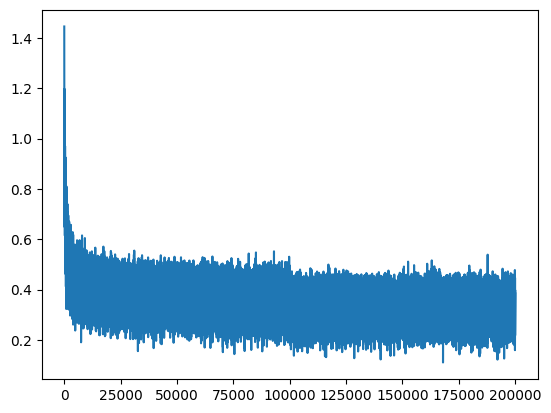

In [9]:
plt.plot(lossi)

In [10]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xtest, Ytest),
    }[split]

    emb = C[x] # (N, block_size, n_embd)
    embcat = emb.view(emb.shape[0], -1) # (N, block_size * n_embd)
    hpreact = embcat @ W1 + b1 # (N, n_hidden)
    h = torch.tanh(hpreact) # (N, n_hidden)
    logits = h @ W2 + b2 # (N, vocab_size)
    loss = F.cross_entropy(logits, y)
    
    print(f"{split} loss: {loss.item():.4f}")

split_loss('train')
split_loss('val')

train loss: 2.1268
val loss: 2.1698


In [11]:
# sample from the model
g = torch.Generator().manual_seed(2147483647)

for _ in range(20):
    out = []
    context = [0] * block_size
    while True:
        emb = C[torch.tensor([context])] # (1, block_size, n_embd)
        embcat = emb.view(1, -1) # (1, block_size * n_embd)
        hpreact = embcat @ W1 + b1 # (1, n_hidden)
        h = torch.tanh(hpreact) # (1, n_hidden)
        logits = h @ W2 + b2 # (1, vocab_size)
        probs = F.softmax(logits, dim=-1)
        # sample from the distribution
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        context = context[1:] + [ix]
        out.append(itos[ix])
        # if we sample the special '.' character, break
        if ix == 0:
            break

    print(''.join(out))

dexzerioullus.
rochi.
ahnell.
imittain.
lucan.
kaida.
samiyah.
javarii.
tai.
moziellah.
jacoredo.
kaley.
maside.
enkavirshif.
bsellini.
gavtarlyn.
kasdra.
aneil.
pynn.
isa.


### Fixing inital loss: Interpreting logits and loss values

A few useful observations about the **logits** (pre-softmax scores) and the **cross-entropy loss** in this MLP:

- **Why logits being near zero is a good baseline**:
  - If all logits are exactly `0`, then `softmax(logits)` produces a **uniform distribution** over all `vocab_size` characters: each has probability `1 / vocab_size`.
  - For our baby-name model, `vocab_size = 27`, so a uniform, untrained model assigns probability `1/27` to every next character.
  - The corresponding **baseline loss** is the negative log of that probability: `-log(1/27) = log(27) ≈ 3.3`.
  - Randomly initialized weights tend to produce logits **with mean near 0** and moderate variance, so the initial softmax is often *close* to uniform, and the initial cross-entropy loss is close to this `≈ 3.3` reference value.

- **Comparing random initialization to a "normal" reference**:
  - Our parameters are initialized from a **zero-mean normal distribution**, so before training, the logits at each position look roughly like a random Gaussian vector.
  - After subtracting the max (which `F.cross_entropy` does internally for numerical stability), exponentiating and normalizing, this behaves similarly to drawing a random probability vector on the simplex.
  - In expectation, this random distribution is **unbiased**: no character is systematically favored, and the expected loss is near the uniform baseline.

- **What the loss curve is telling us**:
  - In the optimization loop above, we start with a very **high loss** (around 21) on tiny minibatches, which quickly drops toward the `~3.3` region as the logits move out of the extreme random regime and toward something closer to uniform.
  - As training progresses, the model starts giving **higher probability to the true next characters** than to others, so the average cross-entropy loss drops well **below** the uniform baseline (e.g. into the low 2s).
  - A much lower loss than `log(vocab_size)` means the model has learned **meaningful structure** in the data; staying near that baseline would indicate that it is effectively guessing at random.

In short: keeping logits roughly centered near 0 at initialization gives a sensible **"uninformative" starting point** (close to uniform predictions and `log(27)` loss), and training then drives the logits away from this regime in a way that **reduces loss** by concentrating probability mass on correct next characters.

### Why scale down `W2` and zero out `b2`?

A common practical trick (used in Karpathy's videos) is to **shrink the output weights** and **zero the output bias**:

- Replace `W2` with `W2 * c` for some constant `c < 1` (e.g. `0.1`).
- Set `b2 = 0` at initialization.

Intuitively, this helps in a few ways:

- **Keeps logits small at the start**: scaling down `W2` makes `h @ W2` have a smaller magnitude, so the logits sit closer to 0. This avoids extremely large positive/negative logits that would make the softmax almost one‑hot and cause **vanishing gradients** for most classes.
- **Stabilizes the initial loss**: with small logits and zero bias, the initial softmax is closer to **uniform**, so the loss starts near the predictable baseline `log(vocab_size)` instead of bouncing around wildly due to huge random scores.
- **Removes arbitrary bias**: setting `b2 = 0` means that, before seeing any data, no character is systematically preferred just because of the bias. All structure must come from learning meaningful patterns in the hidden layer `h` and the weights `W2`.

Overall, this initialization tweak makes the early phase of training **more stable and well‑behaved**, giving gradient descent an easier starting point from which to discover useful patterns.

Total parameters:  11897
00000/200000 loss: 27.8817


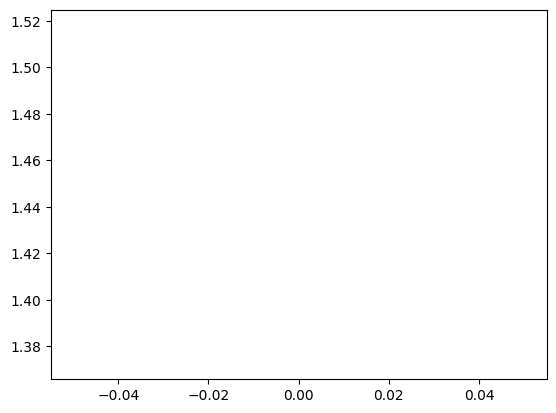

In [12]:
n_embd = 10
n_hidden = 200

# initialize weights
# lambda1 = 0.2
# lambda2 = 0.01
# lambda3 = 0
lambda1 = 1
lambda2 = 1
lambda3 = 1

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, n_embd), generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * lambda1
b1 = torch.randn((n_hidden), generator=g) * lambda2
W2 = torch.randn((n_hidden, vocab_size), generator=g) * lambda2
b2 = torch.randn(vocab_size, generator=g) * lambda3

parameters = [C, W1, b1, W2, b2]

print("Total parameters: ", sum(p.numel() for p in parameters))

for p in parameters:
    p.requires_grad = True

#  Optimization
max_steps = 200_000
batch_size = 32
lossi = []

for i in range(max_steps):

    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]

    # forward pass
    emb = C[Xb] # embed the characters into a dense vector
    embcat = emb.view(emb.shape[0], -1) # flatten the vectors
    hpreact = embcat @ W1 + b1 # hidden layer pre-activation
    h = torch.tanh(hpreact) # hidden layer activation
    logits = h @ W2 + b2 # logits for the next character
    loss = F.cross_entropy(logits, Yb) # compute the loss

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 100_000 else 0.01 # step learning rate decay
    for p in parameters:
        p.data -= lr * p.grad

    # track stats
    if i % 10_000 == 0:
        print(f"{i:05d}/{max_steps:05d} loss: {loss.item():.4f}")

    lossi.append(loss.log10().item())

    # want to visualize for first step only
    break

plt.plot(lossi)

### Smoothing out the "hockey stick" loss curve

If we initialize the model naively, the training loss curve often has a **"hockey stick" shape**:

- It starts off **extremely large** for the first few iterations (the long vertical handle of the stick).
- Then it **rapidly crashes down** toward a more reasonable range (the flat blade), before settling into a slower, more informative descent.

This shape is usually a symptom of the model starting in a **pathological regime**:

- Very large random logits make the softmax **almost one-hot**, so the loss on many examples becomes huge.
- Gradients can be either **tiny** (for saturated probabilities) or **exploding** (for the few classes with massive negative logits), making early updates noisy and hard to interpret.

By using the tricks described above (e.g. **scaling down `W2`**, **zeroing `b2`**, keeping logits near 0 initially), we:

- Start with logits where the softmax is **closer to uniform**, so the initial loss is near the predictable baseline `log(vocab_size)` instead of some enormous value.
- Get a loss curve that **starts in a sensible range and then decreases smoothly**, which makes it much easier to
  - debug optimization issues,
  - compare different hyperparameters fairly,
  - and reason about whether the model is under/overfitting.

In other words, removing the hockey stick shape doesn’t just look nicer on a plot—it reflects a **better-behaved optimization problem**, where gradient descent gets useful signal from the very first steps instead of thrashing through an unstable initial phase.

### Visualizing hidden activations: Fixing the saturated `tanh`

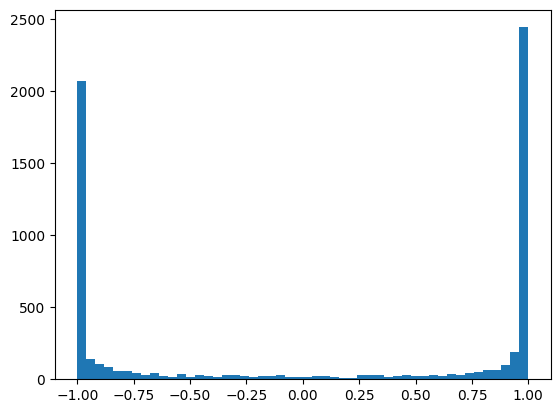

In [13]:
plt.hist(h.view(-1).tolist(), 50);

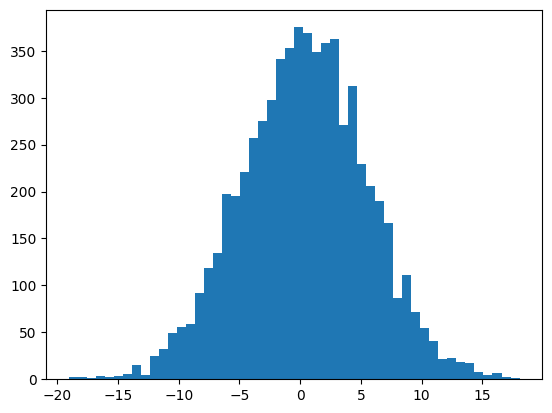

In [14]:
plt.hist(hpreact.view(-1).tolist(), 50);

### Interpreting the hidden pre-activations vs. `tanh` outputs

The two histograms above illustrate an important property of `tanh` networks:

- **`hpreact` (pre-activations)** are roughly **bell-shaped and centered around 0**.
  - Each component of `hpreact` is a **sum of many random contributions** (inputs × weights plus bias), so by a central limit effect it tends to look approximately **Gaussian** with mean near 0.
  - Symmetric initialization of `W1` and `b1` around 0 reinforces this: positive and negative contributions cancel on average.

![tanh curve](images/tanh.png)

- **`h` (after applying `tanh`) is mostly near `-1` or `+1`, with a thinner band around 0.**
  - Whenever `|hpreact|` is large, `tanh(hpreact)` **saturates**: its value is very close to -1 or +1, and its derivative is close to 0.
  - Only when `hpreact` is in a **moderate range around 0** (roughly `[-2, 2]`) does `tanh` behave almost linearly and have a **large derivative**, allowing gradients to flow.

This has two key implications:

- If too many units sit in the saturated regions (histogram mass at the extremes of `h`), the network can suffer from **vanishing gradients**: those neurons barely update during backprop.
- A "healthy" network tries to keep a significant fraction of pre-activations in the **high-slope region** of `tanh`, so the corresponding `h` histogram has a noticeable bump around 0 rather than being almost all at `±1`.

Visualizing these distributions is therefore a useful **diagnostic tool**: it helps you see whether your initialization (and training dynamics) keep the hidden units in an informative regime, or whether they are collapsing into saturation where learning slows down.

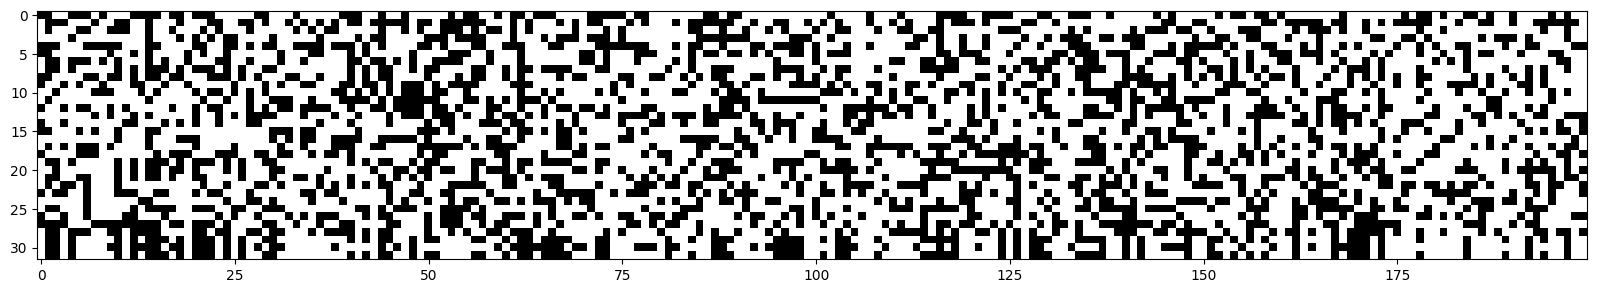

In [15]:
plt.figure(figsize=(20, 10))
plt.imshow(h.abs() > 0.99, cmap='gray', interpolation='nearest')

### Reading the saturation greymap and "dead" neurons

The greymap `plt.imshow(h.abs() > 0.99, cmap='gray')` is plotting, for many examples (rows) and hidden units (columns), **whether each unit is in the saturated region of `tanh`**:

- A **white pixel** means `|h| > 0.99` for that example/unit – the neuron is **saturated** (very close to -1 or +1) and its derivative is tiny.
- A **black pixel** means `|h| ≤ 0.99` – the neuron is in the **high-slope / linear-ish region** of `tanh` where gradients can flow.

If most of the map is white, it means most hidden activations are saturated most of the time, so:

- Gradients through those units are almost zero.
- The model is effectively using only a small "band" of inputs where units occasionally pass through the central region.

A particularly bad pattern is when an **entire column is black** (or nearly so):

- That column corresponds to a **single hidden neuron** that *never* (or almost never) reaches high absolute value; it is always near 0.
- In this case its output is essentially **flat and small** for all training examples, and the downstream weights may never receive a strong signal to change.
- Such a neuron is often called **"dead"** (or at least **inactive**): it contributes almost nothing to the network's predictions and receives almost no meaningful gradient, so it doesn't learn.

By contrast, a healthy hidden layer typically shows a **mix of black and white** in each column: each neuron sometimes saturates but also spends a good fraction of time in the central, high-slope region. This balance lets the network be expressive *and* trainable, whereas too much saturation (or dead columns) is a red flag for initialization or optimization issues.

### Dead neurons across different nonlinearities

![tanh curve](images/activation-functions.png)

The "dead neuron" story Karpathy describes applies well beyond this `tanh` example:

- **Squashing activations (`tanh`, sigmoid)**: if, for every input in the dataset, a neuron’s pre-activation puts it deep into one of the flat tails (for `tanh`, near `±1`; for sigmoid, near `0` or `1`), then its gradient is effectively **zero everywhere**. Its weights and bias stop changing, so the neuron is *dead*.
- **ReLU**: here the flat region is for **negative pre-activations**. A dead ReLU neuron is one that *never* becomes positive on any training example, so its output is always 0 and backprop gives it **exactly zero gradient**.
- Dead neurons can appear **right at initialization** (unlucky random weights/biases) or **during optimization**: with a too‑large learning rate, one update can push a neuron’s pre-activation so far into a flat region that no future example ever reactivates it. From that point on it’s permanent "brain damage" for that unit.

In our saturation greymap, we see many white pixels (lots of saturation), but crucially **no entire column of white**. That means every hidden neuron still sometimes visits the high‑slope region and can receive gradient. So while we have heavy saturation, we are *not* obviously in the worst case where whole neurons are completely dead and never learn.

In our example, our network is small, very shallow so the optimization is easy. It can handle bad initialization but in a large neural network, these problems stackup and many neurons endup as dead neurons.

### Why do we want the pre-activations to be roughly unit-normal?

We want pre-activations to be roughly unit normal (mean 0, variance 1) so that:
- Most values land in the “active” region of tanh <br />
- tanh has useful gradient only near 0: <br />
    - Near x = 0: derivative ≈ 1 (max). <br />
    - For |x| ≳ 2–3: tanh ≈ ±1 and the derivative ≈ 0 (saturated).
- If pre-activations are unit normal, most of them fall in about [-2, 2], where tanh is still curved and the derivative is non‑zero. 
- If the variance is huge, most values are in the tails, tanh is almost always ±1, and gradients are near zero (vanishing gradients, little learning).

#### Gradients can flow
- Backprop multiplies by the derivative of the activation. 
- In the active region that factor is not tiny, so the layer gets a meaningful gradient and can learn. 
- In the saturated region the factor is ≈ 0, so that path is effectively “off” and those units don’t update usefully.
#### No systematic bias toward one side
- Mean 0 means we’re not pushing all pre-activations to one tail (e.g. all positive and saturating at +1). We use both sides of the nonlinearity, which helps with symmetry and learning.
- So: unit normal keeps most pre-activations in the range where tanh (or similar) has a non‑tiny derivative, so the network gets usable gradients and can train. 
- That’s why we scale weights (e.g. 1/√fan_in or Kaiming) and why BatchNorm’s zero-mean, unit-variance output is helpful: in both cases we’re trying to keep the inputs to the activation in that “active” band instead of the flat tails.

### Initial scale for W1: fan-in, variance, and Kaiming

The scale of the first hidden layer’s weights **W1** directly controls the variance of pre-activations **hpreact** and thus how much the hidden units saturate. Choosing the scale well keeps activations and gradients in a reasonable range.

**Variance through a linear layer**

For one layer we have **hpreact = embcat @ W1 + b1**. Suppose:
- **embcat** has shape `(batch, fan_in)` with entries of variance Var(*x*) and mean 0.
- **W1** has shape `(fan_in, n_hidden)` with iid entries of variance Var(*W*) and mean 0.

Then each pre-activation is a sum of `fan_in` terms of the form *x*_i * *W*_ij. If we treat *x* and *W* as independent and zero-mean:

- **Var(hpreact_j) ≈ fan_in × Var(*x*) × Var(*W*)**.

So the variance of the pre-activations **grows with the number of inputs** (fan-in). If we draw W1 from a standard normal (Var(*W*) = 1) and fan_in is large, Var(hpreact) becomes huge and **tanh** saturates almost everywhere.

**Fan-in**

**Fan-in** is the number of inputs feeding into each neuron of the layer. For **W1** in this notebook:

- `embcat` has size `n_embd * block_size` per example (flattened embeddings).
- So **fan_in = n_embd × block_size** (e.g. 10 × 3 = 30). Each of the `n_hidden` neurons sums over these 30 inputs.

- Keeping variance similar: scale by $\frac{1}{√fan_{in}}$

To avoid explosion, we want Var(hpreact) ≈ Var(embcat). So we need:

- **Var(*W*) = 1 / fan_in**  →  **std(W1) = 1 / √fan_in**.

That is the **Xavier/Glorot** style scaling for linear/soft activations: initialize **W1** with a zero-mean distribution with standard deviation **1/√fan_in**. Then the pre-activations have roughly the same scale as the inputs.

**Kaiming (He) initialization**

For **ReLU**, half the pre-activations are set to zero, so the variance of the activations is about **half** the variance of the pre-activations. To compensate, He et al. use a larger scale so that *after* ReLU the variance is preserved. That leads to:

- **std(W1) = √(2 / fan_in)**  (“Kaiming” or “He” initialization).

So:
- **tanh / linear**: use **1/√fan_in** (Xavier).
- **ReLU**: use **√(2/fan_in)** (Kaiming).

In code, for our W1:

```python
fan_in = n_embd * block_size   # number of inputs per neuron
# Xavier-style for tanh:
scale = 1.0 / (fan_in ** 0.5)
# Or Kaiming for ReLU: scale = (2.0 / fan_in) ** 0.5
W1 = torch.randn((fan_in, n_hidden), generator=g) * scale
```

Using too large a scale (e.g. scale 1) makes pre-activations large, so **h = tanh(hpreact)** sits in the flat tails and we get the saturation and “hockey stick” loss discussed above. Using the right scale (e.g. 1/√fan_in for tanh) keeps pre-activations and gradients in a range where the network can learn from the start.

In [16]:
# Fan-in and recommended scale for W1 (for reference; re-run the training cell with this scale to see the effect)

fan_in = n_embd * block_size
print("fan_in (inputs per hidden neuron):", fan_in)

# Xavier-style scale for tanh: keeps Var(hpreact) ~ Var(embcat)
scale_xavier = 1.0 / (fan_in ** 0.5)
print("Xavier scale for tanh (1/sqrt(fan_in)):", scale_xavier)

# Kaiming scale for ReLU: compensates for ReLU zeroing half the activations
scale_kaiming = (2.0 / fan_in) ** 0.5
print("Kaiming scale for ReLU (sqrt(2/fan_in)):", scale_kaiming)

fan_in (inputs per hidden neuron): 30
Xavier scale for tanh (1/sqrt(fan_in)): 0.18257418583505536
Kaiming scale for ReLU (sqrt(2/fan_in)): 0.2581988897471611


**Kaiming in PyTorch**  
PyTorch provides **`torch.nn.init.kaiming_uniform_`** and **`kaiming_normal_`**, which apply the √(2/fan_in) scaling. You pass `mode='fan_in'` (default) or `'fan_out'` and `nonlinearity='relu'`. <br /> When you create an `nn.Linear` layer, its default weight init is Kaiming uniform, so you get this scaling automatically. For a raw tensor: `torch.nn.init.kaiming_normal_(W1, mode='fan_in', nonlinearity='relu')`.

### Batch normalization and why initialization matters less
It helps train deep neural networks reliably.
Insight: We want the hidden activations to be roughly normal. Why not just take them and normalize them to a unit normal? We can do this because the standarization to a unit normal is a perfectly differentiable operation.

**Batch normalization (BatchNorm)** is a layer that normalizes its inputs **per channel** over the **batch dimension**. <br /> For each channel (or unit), it computes the mean and variance across all batch elements, then transforms the values so that the channel has **zero mean and unit variance** on that batch:

- **x_norm = (x - mean) / √(variance + ε)**  
  so that after this step, each channel has mean ≈ 0 and variance ≈ 1 (the "**unit normal**" regime).

Often a **learnable scale (γ)** and **shift (β)** are applied after that: **y = γ * x_norm + β**. So the layer can learn to rescale and recenter if the fixed zero-mean, unit-variance distribution is not ideal.

**Why proper initialization is less critical with BatchNorm**

Without BatchNorm, the scale of **W1** directly sets the scale of **hpreact**; 
- if W1 is too large, pre-activations are huge and tanh/ReLU saturate. With BatchNorm **after** the linear layer (e.g. `hpreact = embcat @ W1 + b1` then `hpreact_bn = BatchNorm(hpreact)` then `h = tanh(hpreact_bn)`), the outputs of the BatchNorm layer are forced into a **unit normal** range (mean 0, variance 1) regardless of how large or small W1 was. <br /> 
- So the *next* layer (or the nonlinearity) always sees inputs in a similar, well-behaved scale. The earlier layer's weights can be initialized with simpler schemes (e.g. standard normal with a small scale); BatchNorm effectively "corrects" the scale and location at runtime. 
- That's why in deep networks that use BatchNorm, people often say **careful initialization (Xavier/Kaiming) is less necessary**: the normalization step keeps activations in a controlled, roughly unit-normal regime so that training is more stable even when initial weights are not perfectly scaled.

### Note:
Since we are normalizing our hidden pre-activations, it's important to note that the bias in the linear layer is redundant, since we are subtracting the mean from the `hpreact`. This results in subtracting out the shifting done by bias.

## Unit normal as a starting point, not the goal

**Why we want it at the beginning**

- At **initialization**, we want pre-activations roughly **unit normal** so that:
  - Most values sit in the **active** region of tanh/ReLU (non‑tiny derivatives).
  - Gradients can flow and training can start without saturation.

So unit normal is a good **default** to make optimization well‑behaved early on.

**Why we don’t want it fixed forever**

- For **better results**, the network should be allowed to **move** that distribution “here and there”:
  - **Different means**: e.g. a neuron that should fire mostly positive can learn a positive bias.
  - **Different scales**: e.g. a neuron that should have large or small magnitude for the task can learn the right scale.
- If we forced activations to stay exactly **N(0, 1)** at every step, we’d be restricting the representational capacity of the network and could hurt final performance.

**How we get both**

- **BatchNorm** gives us the stable, unit‑normal baseline (zero mean, unit variance) so training doesn’t blow up, but then **learnable γ (scale) and β (shift)** let the network *move* that distribution:
  - **β** shifts the mean (“move here and there” in location).
  - **γ** rescales the variance (stronger or weaker activation).
- So we get: **unit normal as a good default**, plus **freedom to move away from it** where that helps the task. That’s why BN uses “normalize then scale/shift” rather than “clamp to N(0,1) forever.”

**Short summary**

- **Unit normal** → good for initialization and for a stable regime so gradients flow.
- **Moving it here and there** (different means/variances per channel or layer) → what we want for learning and better results.
- Learnable scale and shift (e.g. in BatchNorm) are exactly the mechanism that lets the distribution stay unit normal when that’s best and move when it isn’t.

In [17]:
hpreact.mean(0, keepdim=True).shape

torch.Size([1, 200])

In [18]:
hpreact.std(0, keepdim=True).shape

torch.Size([1, 200])

Total parameters:  12297
00000/200000 loss: 3.3147
10000/200000 loss: 2.1984
20000/200000 loss: 2.3375
30000/200000 loss: 2.4359
40000/200000 loss: 2.0119
50000/200000 loss: 2.2595
60000/200000 loss: 2.4775
70000/200000 loss: 2.1020
80000/200000 loss: 2.2788
90000/200000 loss: 2.1862
100000/200000 loss: 1.9474
110000/200000 loss: 2.3010
120000/200000 loss: 1.9837
130000/200000 loss: 2.4523
140000/200000 loss: 2.3839
150000/200000 loss: 2.1987
160000/200000 loss: 1.9733
170000/200000 loss: 1.8668
180000/200000 loss: 1.9973
190000/200000 loss: 1.8347


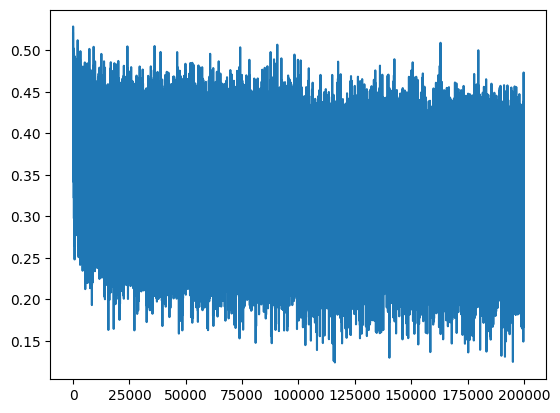

In [ ]:
n_embd = 10
n_hidden = 200

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, n_embd), generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g)  * (5/3) / ((n_embd * block_size)**0.5)
b1 = torch.randn((n_hidden), generator=g) * 0.01
W2 = torch.randn((n_hidden, vocab_size), generator=g) * 0.01
b2 = torch.randn(vocab_size, generator=g) * 0

# initially the hidden activations will be unit normal.
bngain = torch.ones((1, n_hidden))
bnbias = torch.zeros((1, n_hidden))

parameters = [C, W1, b1, W2, b2, bngain, bnbias]

print("Total parameters: ", sum(p.numel() for p in parameters))

for p in parameters:
    p.requires_grad = True

#  Optimization
max_steps = 200_000
batch_size = 32
lossi = []

for i in range(max_steps):

    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]

    # forward pass
    emb = C[Xb] # embed the characters into a dense vector
    embcat = emb.view(emb.shape[0], -1) # flatten the vectors

    # linear layer
    hpreact = embcat @ W1 + b1 # hidden layer pre-activation
    
    # BatchNorm layer: normalize the pre-activations
    hpreact = bngain * (hpreact - hpreact.mean(0, keepdim=True)) / hpreact.std(0, keepdim=True) + bnbias

    h = torch.tanh(hpreact) # hidden layer activation
    logits = h @ W2 + b2 # logits for the next character
    loss = F.cross_entropy(logits, Yb) # compute the loss

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 100_000 else 0.01 # step learning rate decay
    for p in parameters:
        p.data -= lr * p.grad

    # track stats
    if i % 10_000 == 0:
        print(f"{i:05d}/{max_steps:05d} loss: {loss.item():.4f}")

    lossi.append(loss.log10().item())
    # break

plt.plot(lossi)

In [23]:
# calibrate the batch norm at the end of training to avoid mismatch between train and inference

with torch.no_grad():
    # pass the training data through the network
    emb = C[Xtr] # (N, block_size, n_embd)
    embcat = emb.view(emb.shape[0], -1) # (N, block_size * n_embd)
    hpreact = embcat @ W1 + b1 # (N, n_hidden)
    
    # measure the mean and variance of the pre-activations
    bnmean = hpreact.mean(0, keepdim=True)
    bnstd = hpreact.std(0, keepdim=True)

@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xtest, Ytest),
    }[split]

    emb = C[x] # (N, block_size, n_embd)
    embcat = emb.view(emb.shape[0], -1) # (N, block_size * n_embd)
    hpreact = embcat @ W1 + b1 # (N, n_hidden)
    hpreact = bngain * (hpreact - bnmean) / bnstd + bnbias

    h = torch.tanh(hpreact) # (N, n_hidden)
    logits = h @ W2 + b2 # (N, vocab_size)
    loss = F.cross_entropy(logits, y)
    
    print(f"{split} loss: {loss.item():.4f}")

split_loss('train')
split_loss('val')

train loss: 2.0668
val loss: 2.1049


### Running-average batch norm statistics (streaming estimate)

The calibration step above computes `bnmean` and `bnstd` from a **single full pass** over the training set. An alternative, closer to what PyTorch does internally, is to maintain a **running (exponential moving) average** of the batch mean and variance during training:

- For each minibatch we measure `bnmeani` and `bnstdi` from the current `hpreact`.
- We update running estimates with a decay factor (e.g. `decay = 0.99`):
  - `bnmean_running = decay * bnmean_running + (1 - decay) * bnmeani`
  - `bnstd_running  = decay * bnstd_running  + (1 - decay) * bnstdi`
- During **inference**, we normalize with these **running estimates** instead of per-batch stats:
  - `hpreact_bn = bngain * (hpreact - bnmean_running) / bnstd_running + bnbias`

This streaming approach has two advantages:

- It smooths out noise from any single batch and gradually tracks the "population" mean/variance.
- It avoids a separate full-dataset pass at the end: the running averages are built up *as you train* and can be used directly for inference.

In [24]:
# Example: computing running-avg batch norm stats over the training set (after training)

decay = 0.99
with torch.no_grad():
    # initialize running estimates
    bnmean_running = torch.zeros(1, n_hidden)
    bnstd_running  = torch.ones(1, n_hidden)

    # stream over the training data in minibatches
    for i in range(0, Xtr.shape[0], batch_size):
        xb = Xtr[i:i+batch_size]
        emb = C[xb]                               # (B, block_size, n_embd)
        embcat = emb.view(emb.shape[0], -1)       # (B, block_size * n_embd)
        hpreact = embcat @ W1 + b1                # (B, n_hidden)

        bnmeani = hpreact.mean(0, keepdim=True)
        bnstdi  = hpreact.std(0, keepdim=True)

        # exponential moving average update
        bnmean_running = decay * bnmean_running + (1 - decay) * bnmeani
        bnstd_running  = decay * bnstd_running  + (1 - decay) * bnstdi

print("bnmean_running.shape:", bnmean_running.shape)
print("bnstd_running.shape: ", bnstd_running.shape)

# At inference time you would then do:
# hpreact_bn = bngain * (hpreact - bnmean_running) / bnstd_running + bnbias

bnmean_running.shape: torch.Size([1, 200])
bnstd_running.shape:  torch.Size([1, 200])


/var/folders/7x/6jy7bspj7h1bjyhcrx746g6h0000gn/T/ipykernel_29601/1441169629.py:17: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/ReduceOps.cpp:1857.)
  bnstdi  = hpreact.std(0, keepdim=True)


## Why Batch Normalization can be “bad” (downsides / trade-offs)

BatchNorm is often great for training stability, but it has real costs and failure modes:

- **Train/inference mismatch**
  - During training it uses **batch mean/variance**; during inference it uses **running averages**.
  - If your running stats are poorly estimated (small batches, non-stationary data, distribution shift), inference can degrade.

- **Doesn’t like small batch sizes**
  - With small batches, batch statistics are noisy → training becomes unstable or slower.
  - Common in big models (memory limits), detection/segmentation, RL, or sequence models.

- **Couples examples inside a batch**
  - Each example’s activation depends on the other examples in the same batch.
  - This can make training behavior sensitive to batch composition and makes some analyses/debugging harder.

- **Multi-device / distributed training complexity**
  - If you train across multiple GPUs, per-device BatchNorm uses per-device stats (effectively smaller batch).
  - “SyncBatchNorm” fixes that by syncing stats but adds communication overhead and complexity.

- **Awkward with variable-length sequences / autoregressive models**
  - In RNNs/Transformers (especially autoregressive), you don’t want future tokens influencing current token normalization via batch statistics.
  - This is one reason modern Transformers prefer LayerNorm/RMSNorm over BatchNorm.

- **Extra compute and memory**
  - It adds ops (mean/var) and can reduce throughput; also interacts with fused kernels.

- **Can reduce representational freedom if overused**
  - It normalizes away some information (absolute scale/mean), then adds it back via γ/β, but the inductive bias may be unhelpful in some architectures/tasks.

## Other normalization techniques (common alternatives)

### Layer Normalization (LayerNorm)
- **What it normalizes**: across features **within a single example** (not across the batch).
- **Pros**: works well with **small batches** and **sequence models**; no running stats; same behavior in train/infer.
- **Where used**: Transformers, many modern language models.

### RMSNorm
- **What it normalizes**: like LayerNorm but normalizes by **RMS only** (no mean subtraction).
- **Pros**: simpler, often faster; strong performance in LLMs; stable with small batches.
- **Where used**: many recent Transformer variants.

### Group Normalization (GroupNorm)
- **What it normalizes**: divides channels into groups and normalizes within each group per example.
- **Pros**: stable for **small batches**; good for CNNs (segmentation/detection).
- **Where used**: vision models when batch sizes are small.

### Instance Normalization (InstanceNorm)
- **What it normalizes**: per example, per channel across spatial dimensions.
- **Pros**: good for style invariance; common in style transfer.
- **Cons**: can remove useful “contrast/scale” info for recognition tasks.

### Weight Normalization
- **What it normalizes**: the **weights**, not activations (reparameterizes weight vectors).
- **Pros**: can speed optimization; no batch dependence.
- **Cons**: not always as robust as activation normalization.

### Spectral Normalization
- **What it normalizes**: constrains the **spectral norm** of weights (Lipschitz control).
- **Pros**: stabilizes GAN training; controls exploding activations/gradients.
- **Cons**: adds overhead; not a general-purpose default for all tasks.

### Batch Renormalization / BatchNorm variants
- Tweaks to reduce train/infer mismatch or help small batches, but often replaced by LayerNorm/GroupNorm in modern practice.

## Quick “when to use what”
- **CNNs with large batch**: BatchNorm is often fine.
- **CNNs with small batch**: GroupNorm (or LayerNorm variants).
- **Transformers / language models**: LayerNorm or RMSNorm (BatchNorm is usually a poor fit).
- **GANs**: spectral norm often relevant.

If you tell me your exact context (CNN vs MLP vs Transformer, batch size, single GPU vs multi-GPU), I can recommend the most appropriate normalization and where to place it (pre-activation vs post-activation).

## Pytorchifying our code and training a deeper network

In [51]:
class Linear:

    def __init__(self, fan_in, fan_out, bias=True):
        self.weight = torch.randn((fan_in, fan_out), generator = g) / fan_in**0.5
        self.bias = torch.zeros(fan_out) if bias else None

    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out
    
    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])

class BatchNorm1d:

    def __init__(self, dim, epsilon = 1e-5, momentum = 0.1):
        self.epsilon = epsilon
        self.momentum = momentum
        self.training = True

        # Parameters (trained with backprop)
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)

        # Buffers (trained with running 'momentum update')
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)

    def __call__(self, x):
        # Calculate the forward pass
        if self.training:
            xmean = x.mean(0, keepdim=True) # batch mean
            xvar = x.var(0, keepdim=True) # batch variance
        else:
            xmean = self.running_mean
            xvar = self.running_var

        xhat = (x - xmean) / torch.sqrt(xvar + self.epsilon) # normalize to unit variance
        self.out = self.gamma * xhat + self.beta # scale and shift
        
        # update the buffers
        # only update the buffers if we are training
        if self.training:
            with torch.no_grad():
                self.running_mean = self.momentum * xmean + (1 - self.momentum) * self.running_mean
                self.running_var = self.momentum * xvar + (1 - self.momentum) * self.running_var
        return self.out
    
    def parameters(self):
        return [self.gamma, self.beta]
     
    
class Tanh:

    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out
    
    def parameters(self):
        return []
        
n_embd = 10 # The dimensionality of the character embedding vectors
n_hidden = 100 # The number of neurons in the hidden layer of the MLP
g = torch.Generator().manual_seed(2147483647)

C = torch.randn((vocab_size, n_embd), generator=g)
layers = [
    Linear(n_embd * block_size, n_hidden), Tanh(),
    Linear(n_hidden, n_hidden), Tanh(),
    Linear(n_hidden, n_hidden), Tanh(),
    Linear(n_hidden, n_hidden), Tanh(),
    Linear(n_hidden, n_hidden), Tanh(),
    Linear(n_hidden, vocab_size)
]

with torch.no_grad():
    # make the last layer less confident
    layers[-1].weight *= 0.1
    # all other layers: apply gain
    for layer in layers[:-1]:
        if isinstance(layer, Linear):
            layer.weight *= 5/3

parameters = [C] + [p for layer in layers for p in layer.parameters()]
print("Total parameters: ", sum(p.numel() for p in parameters))
    
for p in parameters:
    p.requires_grad = True

Total parameters:  46497


In [52]:
#  Optimization
max_steps = 200_000
batch_size = 32
lossi = []
ud = []

for i in range(max_steps):

    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]

    # forward pass
    emb = C[Xb] # embed the characters into a dense vector
    x = emb.view(emb.shape[0], -1) # flatten the vectors

    for layer in layers:
        x = layer(x)

    loss = F.cross_entropy(x, Yb)

    # backward pass
    for layer in layers:
        layer.out.retain_grad() # AFTER_DEBUG: would take out retain_graph
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 100_000 else 0.01 # step learning rate decay
    for p in parameters:
        p.data -= lr * p.grad

    # track stats
    if i % 10_000 == 0:
        print(f"{i:05d}/{max_steps:05d} loss: {loss.item():.4f}")
    lossi.append(loss.log10().item())

    # update to data ratio
    with torch.no_grad():
        ud.append([(lr*p.grad.std() / p.data.std()).log10().item() for p in parameters])

    if i > 1000:
        break # AFTER_DEBUG: take out to run after full optimization

00000/200000 loss: 3.2962


Layer 1 (      Tanh): Mean -0.07, Std +0.76, Saturated: 22.19%
Layer 3 (      Tanh): Mean +0.00, Std +0.72, Saturated: 12.16%
Layer 5 (      Tanh): Mean -0.00, Std +0.75, Saturated: 15.00%
Layer 7 (      Tanh): Mean -0.04, Std +0.74, Saturated: 13.25%
Layer 9 (      Tanh): Mean -0.01, Std +0.71, Saturated: 11.22%


Text(0.5, 1.0, 'Activation Distributions')

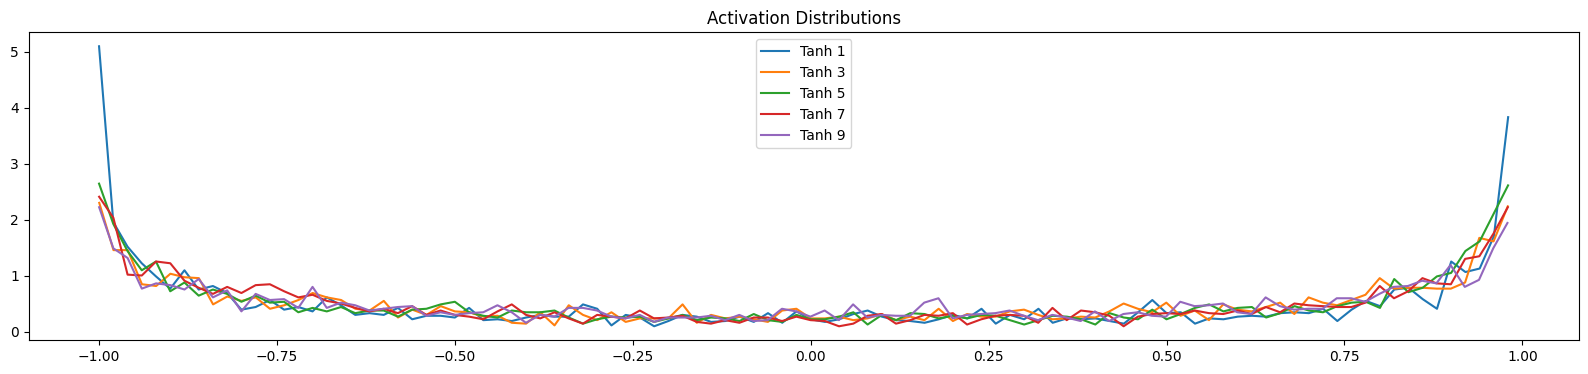

In [53]:
# Visualize histograms
plt.figure(figsize=(20, 4))
legends = []

for i, layer in enumerate(layers[:-1]): # Note: last layer is not visualized
    if isinstance(layer, Tanh):
        t = layer.out
        print('Layer %d (%10s): Mean %+.2f, Std %+.2f, Saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean()*100))
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'{layer.__class__.__name__} {i}')

plt.legend(legends)
plt.title('Activation Distributions')

Layer 1 (      Tanh): Mean -0.000005, Std 3.059084e-03
Layer 3 (      Tanh): Mean +0.000037, Std 3.085332e-03
Layer 5 (      Tanh): Mean -0.000007, Std 2.888205e-03
Layer 7 (      Tanh): Mean +0.000012, Std 2.756315e-03
Layer 9 (      Tanh): Mean +0.000007, Std 2.337389e-03


Text(0.5, 1.0, 'Gradient Distributions')

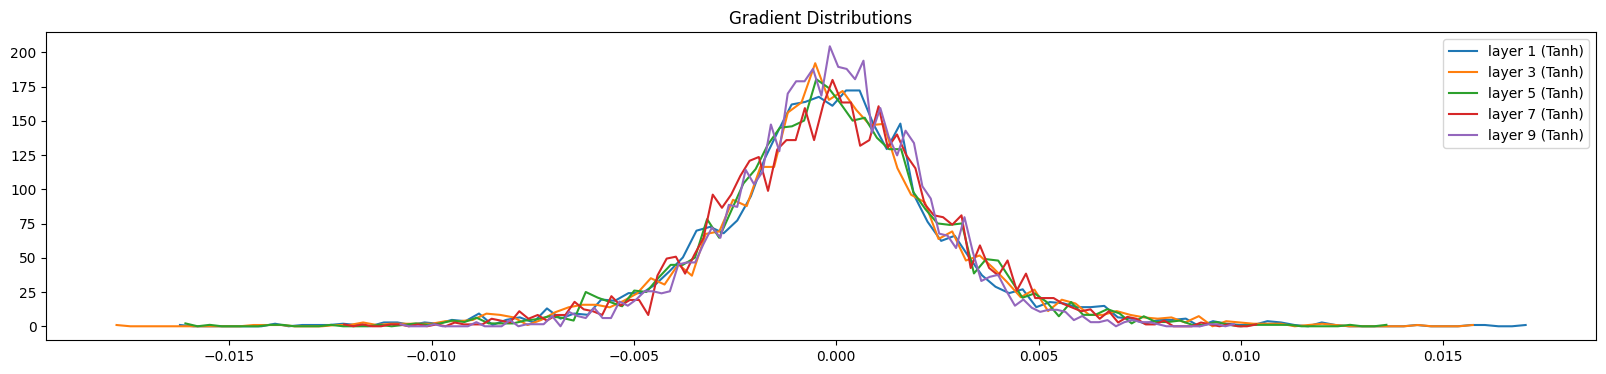

In [54]:
# Visualize the gradient histograms
plt.figure(figsize=(20, 4))
legends = []

for i, layer in enumerate(layers[:-1]): # Note: last layer is not visualized
    if isinstance(layer, Tanh):
        t = layer.out.grad
        print('Layer %d (%10s): Mean %+f, Std %e' % (i, layer.__class__.__name__, t.mean(), t.std()))
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} ({layer.__class__.__name__})')

plt.legend(legends)
plt.title('Gradient Distributions')

weight   (27, 10) | mean: +0.000772, std: 9.714627e-03 | grad:data ratio 9.714513e-03
weight  (30, 100) | mean: -0.000036, std: 8.734049e-03 | grad:data ratio 2.792836e-02
weight (100, 100) | mean: +0.000085, std: 7.424628e-03 | grad:data ratio 4.417372e-02
weight (100, 100) | mean: +0.000055, std: 6.242014e-03 | grad:data ratio 3.681917e-02
weight (100, 100) | mean: +0.000007, std: 6.161663e-03 | grad:data ratio 3.650615e-02
weight (100, 100) | mean: +0.000069, std: 5.221998e-03 | grad:data ratio 3.102274e-02
weight  (100, 27) | mean: +0.000000, std: 2.281147e-02 | grad:data ratio 3.229574e-01


Text(0.5, 1.0, 'Weights Gradients distribution')

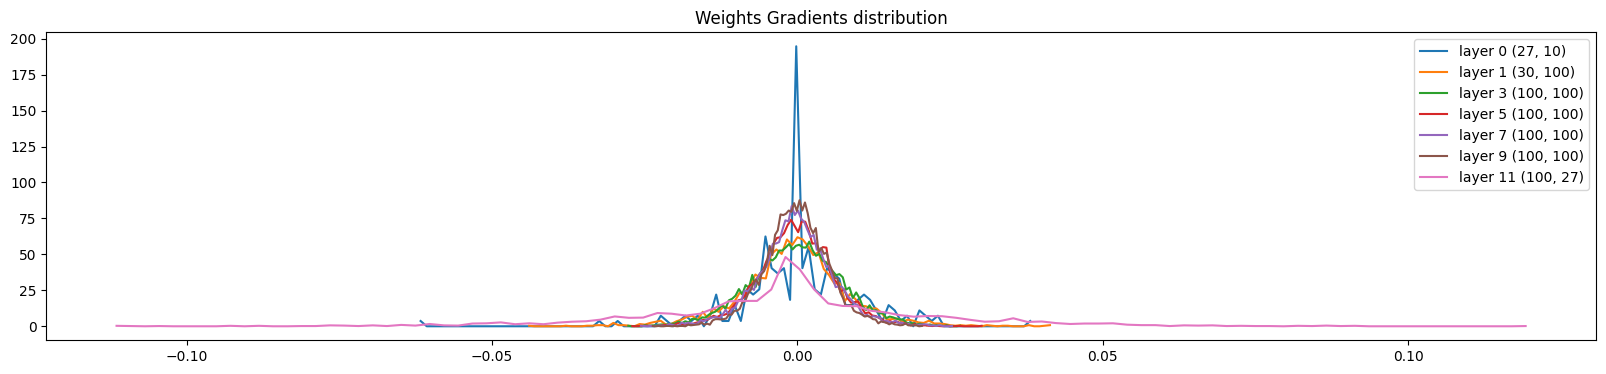

In [55]:
# Visualizing the parameter values and gradients
plt.figure(figsize=(20, 4))
legends = []

for i, p in enumerate(parameters):
    t = p.grad
    # Only visualize weights of linear layers, skipping the biases, gamma, betas
    if p.ndim == 2:
        print('weight %10s | mean: %+f, std: %e | grad:data ratio %e' % (tuple(p.shape), t.mean(), t.std(), t.std()/p.std()))
        hy, hx = torch.histogram(t.view(-1), density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} {tuple(p.shape)}')

plt.legend(legends)
plt.title('Weights Gradients distribution')

        

Text(0.5, 1.0, 'Update to data ratio')

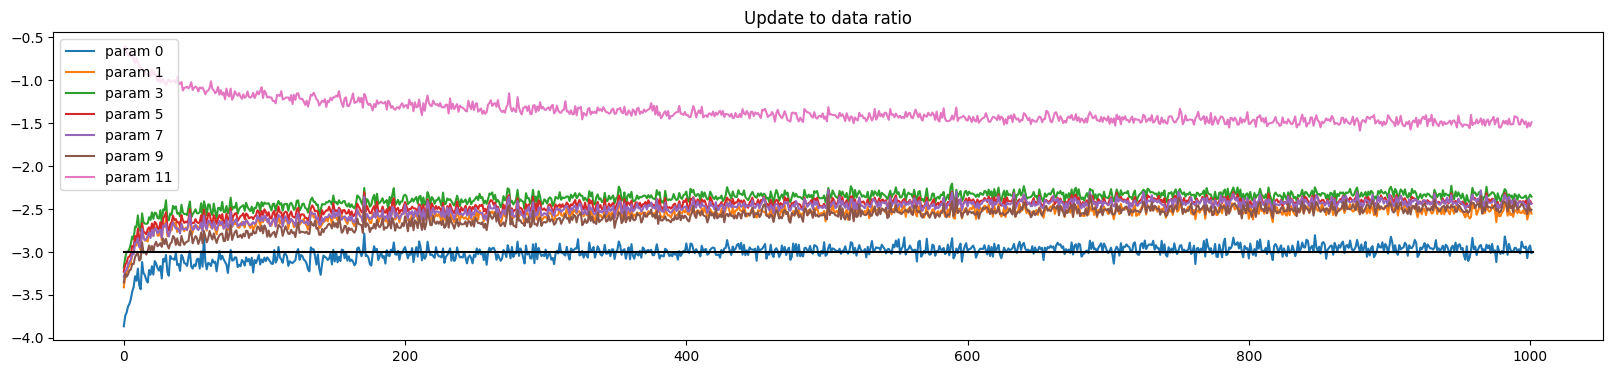

In [56]:
plt.figure(figsize = (20, 4))
legends = []
for i, p in enumerate(parameters):
    if p.ndim == 2:
        plt.plot([ud[j][i] for j in range(len(ud))])
        legends.append('param %d' % i)

plt.plot([0, len(ud)],[-3, -3], 'k') # these ratios should be around 1e-3
plt.legend(legends)
plt.title('Update to data ratio')

Updates are getting stable over training. The last layer is an outlier because we made it to be less confident during initialization (we had multiplied it by -1).